# What is BERT?

**BERT ** is an encoder only transformer for Natural Language Understanding (NLU). It is pre-trained using the following objectives:
- MLM - Masked Language Modeling
- NSP - Next Sentence Prediction

During **pre-training (self-supervised learning)**, BERT learns bidirectional contextual representations by predicting masked tokens and modeling sentence-level relationships.

After pre-training, BERT is **fine-tuned on labeled data** for downstream tasks such as:

  - Question Answering (QA)
  - Named Entity Recognition (NER)
  - Natural Language Inference (MNLI)
  - Text Classification

**Highlights about BERT**:
- Uses WordPiece tokenization with a vocabulary size of **~30,000** tokens.
- The first token of every input sequence is a special classification token [CLS], whose final hidden state is used for classification tasks.
- Sentence pairs are separated using the special token [SEP].
- The [MASK] token is used only during pre-training and does not appear during fine-tuning or inference.
- For **MLM** pre-training, 15% of tokens in a sentence is replaced with [MASK] token.
- BERT is pre-trained by its inventor using BooksCorpus (800M words) and Enlighs Wikipedia (2500M words).
- BERT is evaluated using GLUE and its performance is 86%.


# BERT Architecture

![architecture](https://towardsdatascience.com/wp-content/uploads/2024/05/16Vy32tUuqtAwz24CfS83wg-1.png)

**Classification Layer or Output Layer(Linear + Softmax)** depends on the specific downstream tasks.

![bert](https://media.beehiiv.com/cdn-cgi/image/fit=scale-down,format=auto,onerror=redirect,quality=80/uploads/asset/file/f32aa340-1125-4620-b4e7-fde680532471/Copy_of_Copy_of_Copy_of_Copy_of_Copy_of_Copy_of_Copy_of_Copy_of_Copy_of_Copy_of_Copy_of_Copy_of_Copy_of_Add_a_heading__720_x_600_px_.png?t=1744566453)

BERT output layer predicts the [MASK] token.
**Softmax** generates a probability distribution of 30K vocabs for [MASK] token. You then pick the vocab with highest probability

# Embeddings in BERT Encoder

### Input -> Token Embeddings

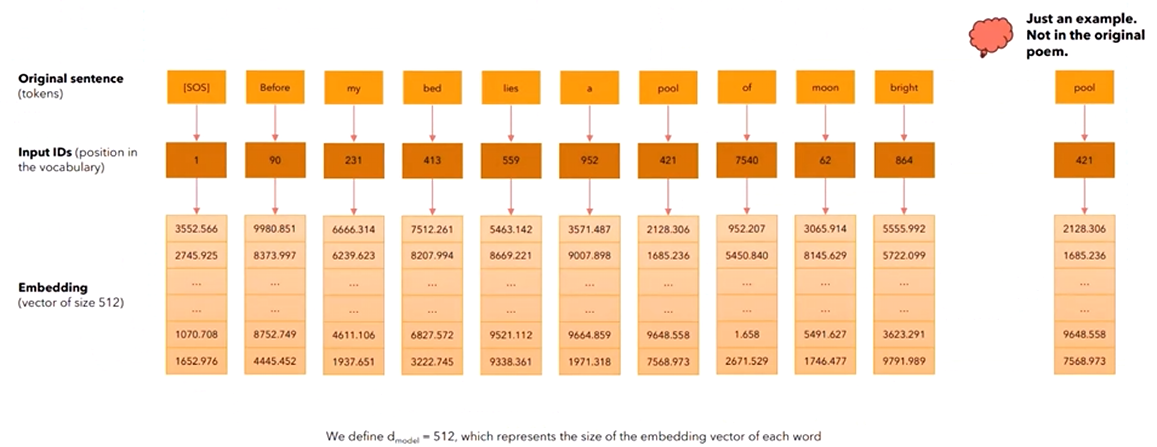

### Add Segment and Positional Embeddings

![encoder](https://d2l.ai/_images/bert-input.svg)

**Segment embeddings** (also called token type embeddings) tell the model which sentence a token belongs to when multiple sentences are provided as input. You do not see it in Decoder, but in BERT encoder.

Why? Because, BERT was designed to handle sentence pairs as a core use case.

Examples:
- Question + Answer (QA)
- Premise + Hypothesis (NLI)
- Sentence A + Sentence B (NSP task)

**Decoder** models are causal and they process tokens from left-->right, one sequence at a time. Hence, it does not have the segment embedding.

# BERT Output Layer

![output](https://miro.medium.com/v2/resize:fit:972/0*dcogCa94s8dMlIw2.PNG)

### BERT Output Layer Explained

- **MLM (Masked Language Modeling):**
During pre-training, the hidden state corresponding to each [MASK] token is passed through an MLM prediction head (Linear → Softmax) to produce a probability distribution over the vocabulary (~30k tokens).
The token with the highest probability is selected as the prediction for the masked position.

- **NSP (Next Sentence Prediction):**
During pre-training, only the hidden state of the [CLS] token (the first token) is used. This vector is passed through a **binary classification** head to predict whether Sentence B logically follows Sentence A.